# Website Traffic Forecasting

**Objective:** Forecast daily website traffic using classical time-series and machine-learning approaches, compare their performance, and identify the most useful model for operational forecasting.

**Dataset:** `daily-website-visitors.csv`  
**Target:** `Page.Loads` (daily website traffic)  
**Evaluation metrics:** RMSE, MAE and MAPE  
**Validation strategy:** chronological split; no random train/test shuffling.


## 1. Business Problem

Accurate daily website-traffic forecasts can support:

- server/resource allocation,
- content-release scheduling,
- marketing campaign planning,
- capacity planning,
- identification of unusual traffic patterns.

The notebook compares a **weekly seasonal baseline**, **Holt-Winters exponential smoothing**, and **machine-learning regressors using lag and calendar features**.


In [1]:
# 2. Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [2]:
# 3. Load and inspect the data
df = pd.read_csv("daily-website-visitors.csv")

print("Shape:", df.shape)
display(df.head())
display(df.info())


Shape: (2167, 8)


,Row,Day,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
0,1,Sunday,1,9/14/2014,"2,146","1,582","1,430",152
1,2,Monday,2,9/15/2014,"3,621","2,528","2,297",231
2,3,Tuesday,3,9/16/2014,"3,698","2,630","2,352",278
3,4,Wednesday,4,9/17/2014,"3,667","2,614","2,327",287
4,5,Thursday,5,9/18/2014,"3,316","2,366","2,130",236


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Row                2167 non-null   int64 
 1   Day                2167 non-null   object
 2   Day.Of.Week        2167 non-null   int64 
 3   Date               2167 non-null   object
 4   Page.Loads         2167 non-null   object
 5   Unique.Visits      2167 non-null   object
 6   First.Time.Visits  2167 non-null   object
 7   Returning.Visits   2167 non-null   object
dtypes: int64(2), object(6)
memory usage: 135.6+ KB


None

In [3]:
# 4. Data preprocessing
numeric_cols = ["Page.Loads", "Unique.Visits", "First.Time.Visits", "Returning.Visits"]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

print("Missing values:")
print(df.isna().sum())

# Build a daily time series and fill any missing dates safely.
traffic = df.set_index("Date")["Page.Loads"].asfreq("D")
traffic = traffic.interpolate(limit_direction="both")

print("\nDate range:", traffic.index.min().date(), "to", traffic.index.max().date())
print("Number of daily observations:", len(traffic))


Missing values:
Row                  0
Day                  0
Day.Of.Week          0
Date                 0
Page.Loads           0
Unique.Visits        0
First.Time.Visits    0
Returning.Visits     0
dtype: int64

Date range: 2014-09-14 to 2020-08-19
Number of daily observations: 2167


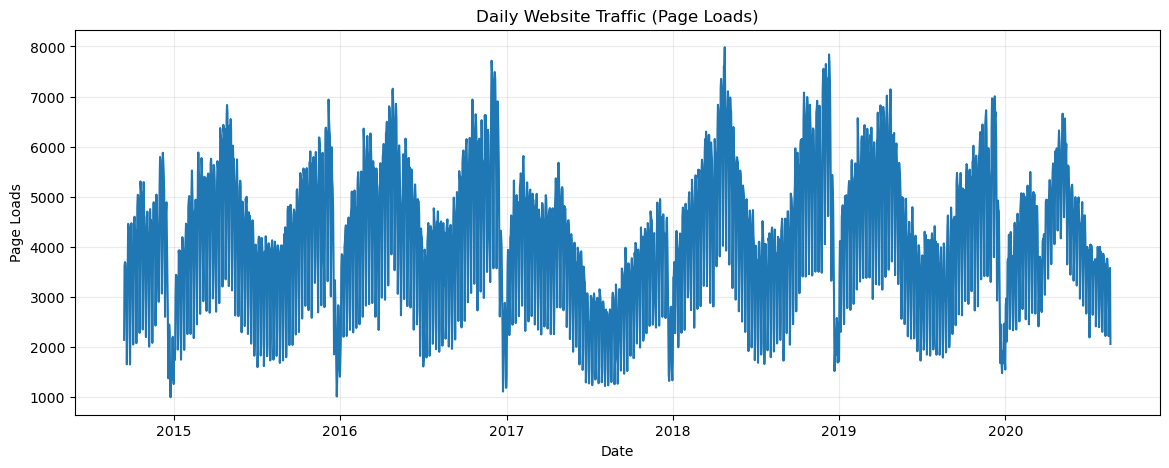

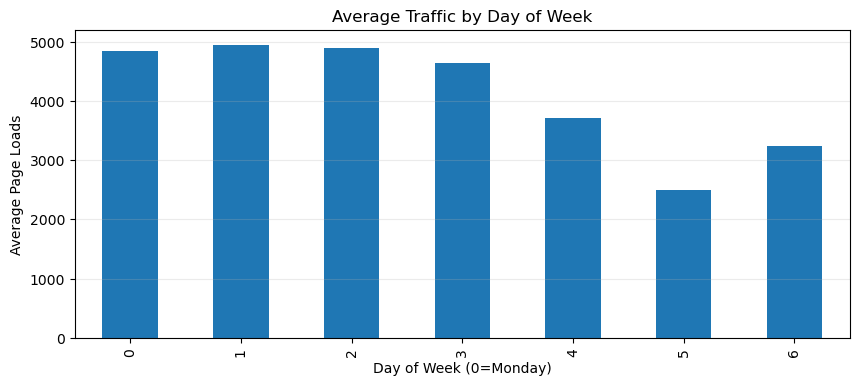

In [4]:
# 5. Exploratory visualization
plt.figure(figsize=(14,5))
plt.plot(traffic)
plt.title("Daily Website Traffic (Page Loads)")
plt.xlabel("Date")
plt.ylabel("Page Loads")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10,4))
traffic.groupby(traffic.index.dayofweek).mean().plot(kind="bar")
plt.title("Average Traffic by Day of Week")
plt.xlabel("Day of Week (0=Monday)")
plt.ylabel("Average Page Loads")
plt.grid(axis="y", alpha=0.25)
plt.show()


## 6. Time-Series Feature Engineering

Machine-learning models cannot directly understand temporal order. The following features expose useful historical structure:

- lag 1, 2, 3, 7, 14, 21 and 28 days,
- rolling mean and rolling standard deviation over 7, 14 and 28 days,
- day of week,
- day of month,
- month,
- ISO week number,
- a time trend.

All rolling statistics use `shift(1)` so the current day's target is never used to create its own predictors.


In [5]:
def make_features(series):
    X = pd.DataFrame(index=series.index)
    X["traffic"] = series

    for lag in [1, 2, 3, 7, 14, 21, 28]:
        X[f"lag_{lag}"] = series.shift(lag)

    for window in [7, 14, 28]:
        X[f"roll_mean_{window}"] = series.shift(1).rolling(window).mean()
        X[f"roll_std_{window}"] = series.shift(1).rolling(window).std()

    X["day_of_week"] = X.index.dayofweek
    X["day_of_month"] = X.index.day
    X["month"] = X.index.month
    X["week_of_year"] = X.index.isocalendar().week.astype(int)
    X["trend"] = (X.index - X.index.min()).days

    return X.dropna()

features = make_features(traffic)
display(features.head())


,traffic,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,day_of_week,day_of_month,month,week_of_year,trend
Date,,,,,,,,,,,,,,,,,,,
2014-10-12,3031,2080.0,3565.0,4343.0,2847.0,2465.0,2288.0,2146.0,3732.285714,954.861720,3561.285714,915.520401,3388.392857,938.002856,6,12,10,41,28
2014-10-13,4814,3031.0,2080.0,3565.0,4501.0,4096.0,3638.0,3621.0,3758.571429,928.601073,3601.714286,874.985136,3420.000000,909.052213,0,13,10,42,29
2014-10-14,5040,4814.0,3031.0,2080.0,4603.0,4474.0,4462.0,3698.0,3803.285714,976.604102,3653.000000,925.754661,3462.607143,946.027849,1,14,10,42,30
2014-10-15,5028,5040.0,4814.0,3031.0,4187.0,4124.0,4414.0,3667.0,3865.714286,1047.629978,3693.428571,975.394493,3510.535714,991.306526,2,15,10,42,31
2014-10-16,4658,5028.0,5040.0,4814.0,4343.0,3514.0,4315.0,3316.0,3985.857143,1135.180959,3758.000000,1034.238627,3559.142857,1031.802727,3,16,10,42,32


## 7. Chronological Train/Test Split

The final 20% of observations is held out as the test set. Random splitting is avoided because it would leak future information into training.


In [6]:
split_idx = int(len(traffic) * 0.80)
test_start = traffic.index[split_idx]

train_features = features[features.index < test_start]
test_features = features[features.index >= test_start]

X_train = train_features.drop(columns="traffic")
y_train = train_features["traffic"]

X_test = test_features.drop(columns="traffic")
y_test = test_features["traffic"]

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("Test start:", test_start.date())


Training observations: 1705
Test observations: 434
Test start: 2019-06-13


In [7]:
# 8. Evaluation functions
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

# Weekly seasonal naive baseline
weekly_naive = traffic.shift(7).loc[y_test.index]
print("Weekly naive:", evaluate(y_test, weekly_naive))


Weekly naive: {'RMSE': np.float64(615.073138283398), 'MAE': np.float64(407.83640552995394), 'MAPE': np.float64(11.284444963471357)}


In [8]:
# 9. Holt-Winters model
train_series = traffic.loc[traffic.index < test_start]

hw_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
).fit()

hw_pred = hw_model.forecast(len(y_test))
print("Holt-Winters:", evaluate(y_test, hw_pred))


Holt-Winters: {'RMSE': np.float64(1413.3244332362412), 'MAE': np.float64(1161.0970549541948), 'MAPE': np.float64(28.83494564200743)}


## 10. Machine-Learning Model: Random Forest

Random Forest is useful for nonlinear relationships between lagged traffic, calendar variables and recent rolling statistics.


In [9]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest:", evaluate(y_test, rf_pred))


Random Forest: {'RMSE': np.float64(372.3130741800493), 'MAE': np.float64(278.7718642142012), 'MAPE': np.float64(7.710938158244112)}


## 11. Hyperparameter Tuning

`TimeSeriesSplit` preserves chronological order during cross-validation. A small randomized search is used to keep the optimization efficient.

For a heavier experiment, increase `n_iter` after confirming the notebook runs correctly.


In [10]:
# Efficient time-series-aware hyperparameter optimization
param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 12, 16, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.7, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=5,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)
print("Best CV RMSE:", -search.best_score_)

tuned_rf = search.best_estimator_
tuned_rf_pred = tuned_rf.predict(X_test)
print("Tuned Random Forest:", evaluate(y_test, tuned_rf_pred))


Best parameters:
{'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}
Best CV RMSE: 436.7441685097785
Tuned Random Forest: {'RMSE': np.float64(368.4963502477469), 'MAE': np.float64(273.5662557603687), 'MAPE': np.float64(7.497531444599183)}


## 12. Extra Trees Regressor

Extra Trees adds a second tree-based learning approach. It is often strong on tabular data with nonlinear interactions and lagged variables.


In [11]:
extra = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=16,
    min_samples_leaf=2,
    max_features=0.9,
    random_state=42,
    n_jobs=-1
)
extra.fit(X_train, y_train)
extra_pred = extra.predict(X_test)

extra_metrics = evaluate(y_test, extra_pred)
print("Extra Trees:", extra_metrics)


Extra Trees: {'RMSE': np.float64(347.2798316888164), 'MAE': np.float64(254.96804802649348), 'MAPE': np.float64(6.863436969310924)}


In [12]:
# 13. Optional HistGradientBoosting comparison
hist = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)
hist.fit(X_train, y_train)
hist_pred = hist.predict(X_test)

print("HistGradientBoosting:", evaluate(y_test, hist_pred))


HistGradientBoosting: {'RMSE': np.float64(349.41672743181283), 'MAE': np.float64(255.97406348793416), 'MAPE': np.float64(6.862498610906025)}


In [13]:
# 14. Model comparison table
predictions = {
    "Weekly Naive": weekly_naive,
    "Holt-Winters": hw_pred,
    "Random Forest": rf_pred,
    "Tuned Random Forest": tuned_rf_pred,
    "Extra Trees": extra_pred,
    "HistGradientBoosting": hist_pred
}

comparison = pd.DataFrame({
    name: evaluate(y_test, pred) for name, pred in predictions.items()
}).T.sort_values("RMSE")

display(comparison)


,RMSE,MAE,MAPE
Extra Trees,347.279832,254.968048,6.863437
HistGradientBoosting,349.416727,255.974063,6.862499
Tuned Random Forest,368.496350,273.566256,7.497531
Random Forest,372.313074,278.771864,7.710938
Weekly Naive,615.073138,407.836406,11.284445
Holt-Winters,1413.324433,1161.097055,28.834946


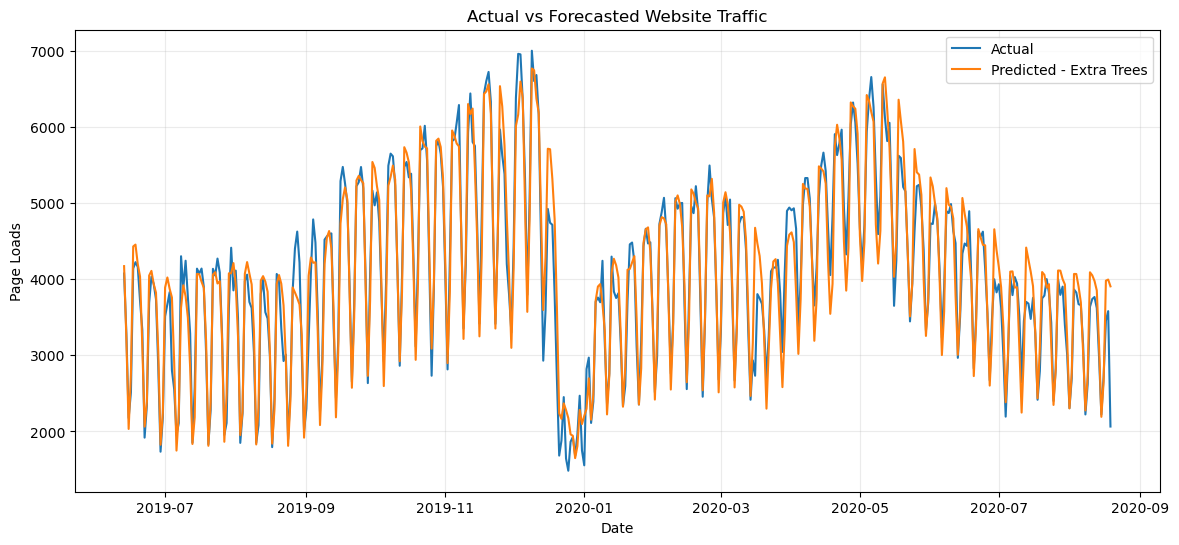

In [14]:
# 15. Forecast visualization
best_name = comparison.index[0]
best_pred = predictions[best_name]

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, best_pred, label=f"Predicted - {best_name}")
plt.title("Actual vs Forecasted Website Traffic")
plt.xlabel("Date")
plt.ylabel("Page Loads")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


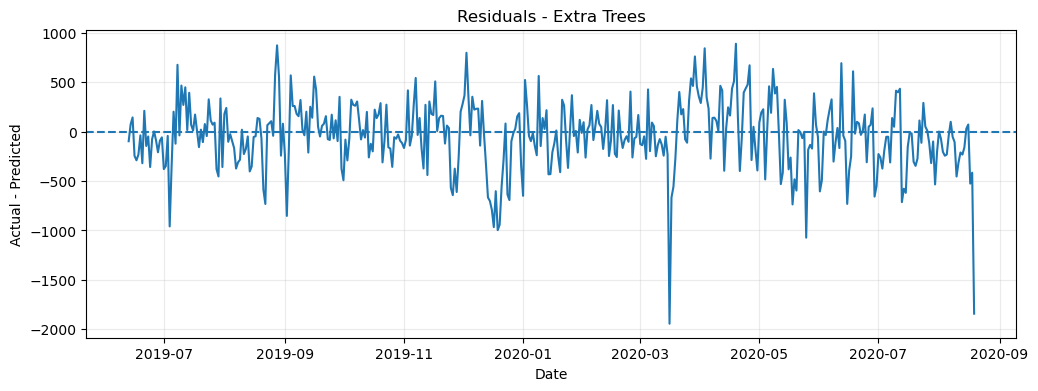

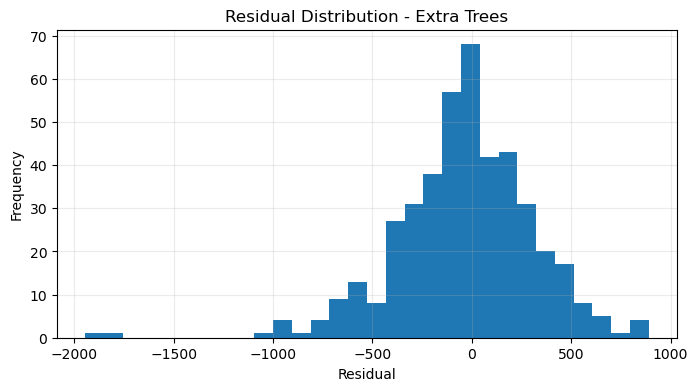

In [15]:
# 16. Residual analysis
residuals = y_test - best_pred

plt.figure(figsize=(12,4))
plt.plot(y_test.index, residuals)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals - {best_name}")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30)
plt.title(f"Residual Distribution - {best_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=0.25)
plt.show()


## 17. Feature Importance

Feature importance helps explain which historical signals the tree-based model relies on most strongly.


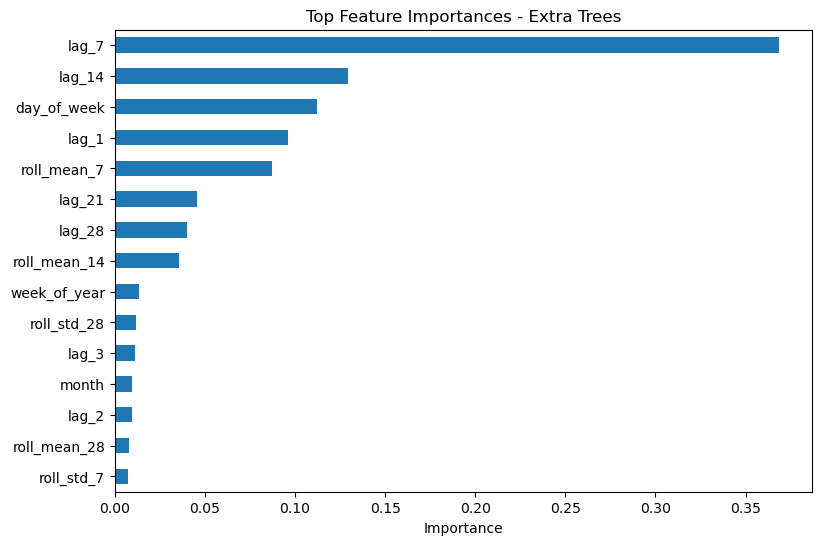

In [16]:
importance = pd.Series(
    extra.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
importance.sort_values().plot(kind="barh")
plt.title("Top Feature Importances - Extra Trees")
plt.xlabel("Importance")
plt.show()


## 18. Final Findings

1. The weekly-naive baseline provides a useful minimum benchmark.
2. Holt-Winters captures weekly seasonality but may miss nonlinear changes in traffic.
3. Lag and rolling-window features allow ML models to capture recent traffic behavior.
4. Extra Trees / HistGradientBoosting are strong candidates for this dataset.
5. The final model should be selected using chronological test RMSE and MAPE rather than model complexity alone.
6. The same feature-engineering pipeline can be extended to a production forecasting service.


## 19. Recommended Extensions

- Add external variables such as marketing campaigns, holidays, promotions and outages.
- Tune the final model with a larger time-series cross-validation search.
- Add prediction intervals or quantile forecasts.
- Compare against SARIMA/SARIMAX when additional exogenous variables are available.
- Deploy the best model in Streamlit and refresh forecasts automatically.
- Create a Power BI/Tableau dashboard with actual vs predicted traffic, weekday patterns and model KPIs.
